<sub>Developed by SeongKu Kang, August 2025 — Do not distribute</sub>

# 📘 P1a. Data Exploration

In this notebook, we explore the (simplified) **E-commerce dataset** to understand what information is provided in each file.  
Data exploration is more than just loading files — it helps us identify what the inputs and outputs look like, and prepares us for building retrieval and classification models later.

In this stage, we will:
1. **Load the provided files** (e.g., JSON, TSV, or CSV) and inspect their structure  
2. **Check the key fields** such as `query`, `product_id`, `product_title`, and `label`  
3. **Display a few samples** to get a concrete sense of the data  
4. **Look at simple statistics** like dataset size and label distribution  

Think of this part as the process of **getting familiar with the data**.  
By thoroughly understanding it beforehand, we will be able to make better decisions in later steps, such as preprocessing, model design, and evaluation.

In [1]:
from pathlib import Path
import json
import random
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Default paths
ROOT = Path("dataset") # Root dataset directory
CORPUS_PATH = ROOT / "corpus.jsonl" # Product corpus file (JSON Lines): Each line contains a product ID and its associated text description.
QUERIES_1K_PATH = ROOT / "queries_1k.jsonl" # Query dataset (JSON Lines): each line contains queryID, query and associated product IDs

# Task 1: Product category classification
LABEL_MAP_PATH = ROOT / "category_classification" # Folder containing label mapping files and product-to-label mappings
LABEL2ID_PATH = LABEL_MAP_PATH / "label2labelid.json" # Mapping from category label string → numeric label ID
ID2LABEL_PATH = LABEL_MAP_PATH / "labelid2label.json" # Mapping from numeric label ID → category label string
PID2LABEL_TRAIN_PATH = LABEL_MAP_PATH / "pid2labelids_train.json" # Mapping from product ID → label ID for the training set
PID2LABEL_TEST_PATH = LABEL_MAP_PATH / "pid2labelids_test.json" # Mapping from product ID → label ID for the test set

# Task 2: ESCI classification & Task 3: Product retrieval
QRELS_TRAIN_PATH = ROOT / "qrels_1k.tsv"
QRELS_TEST_PATH = ROOT / "qrels_test.tsv"

# Additional metadata (product brand)
PRODUCT2BRAND_PATH = ROOT / "product_brand_map.json"

In [2]:
# === Helpers: JSON / JSONL loaders ===
def load_json(path):
    """Load a JSON file as a Python dict."""
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def read_jsonl_to_df(path):
    """Load a JSON Lines file into a pandas DataFrame (one JSON per line)."""
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

## A. Corpus & Queries

### Corpus

In [3]:
# === Load corpus.jsonl: product_id (_id), title, text ===
df_corpus = read_jsonl_to_df(CORPUS_PATH)

print("Corpus shape:", df_corpus.shape)
print("Columns:", df_corpus.columns.tolist())
df_corpus.tail(5)

Corpus shape: (39452, 3)
Columns: ['_id', 'title', 'text']


,_id,title,text
39447,B07HH7RRCQ,Amazon Essentials Men's 2-Pack Slim-Fit Short-...,"Fits close to the body for fitted, slim silho..."
39448,B07HPZN86H,"Soffe Men's Striped Sleeve Tee, Navy, XX-Large",Two white screen printed stripes on both uppe...
39449,B07HRGHKQ5,Nautica Men's Classic Fit Short Sleeve Dual Ti...,"Stand collar, 3-button placket closure Ribbed..."
39450,B00LWHUSPM,DRI-EQUIP Long Sleeve Moisture Wicking Athleti...,DRI-EQUIP Long Sleeve Moisture Wicking Athleti...
39451,B071F121YC,BALEAF Men's Long Sleeve Shirts Lightweight UP...,1.UV Protection - With UV protection of UPF50+...


In [4]:
# === Basic checks for corpus ===
assert {"_id","title","text"}.issubset(df_corpus.columns), "Missing required columns in corpus."
n_docs = len(df_corpus)
n_unique_ids = df_corpus["_id"].nunique()
print(f"#Documents: {n_docs} | #Unique _id: {n_unique_ids} | Duplicates:", n_docs - n_unique_ids)
print("Missing title:", df_corpus["title"].isna().sum())

#Documents: 39452 | #Unique _id: 39452 | Duplicates: 0
Missing title: 0


### Queries

In [5]:
df_queries = read_jsonl_to_df(QUERIES_1K_PATH)
df_queries = df_queries.drop_duplicates(subset=["query_id", "query"]).drop(columns=["product_id"]) # we don't need this column at this moment

print("Queries shape:", df_queries.shape)
print("Columns:", df_queries.columns.tolist())
df_queries.tail(5)

Queries shape: (1000, 2)
Columns: ['query_id', 'query']


,query_id,query
20175,106100,twin xl comforter sets for college girls
20215,44439,gardening tools starter kit
20231,51233,hooka hoes
20247,32121,deep wrinkle filler serum
20263,35946,dumper dogg


## Task 1: Product category classification

In this task, we use **product information** (e.g., title, description) as input, and train a model to classify each product into the correct **category**.   
Note that queries are not used in this task.

In [6]:
# === Load label maps: label <-> id ===
label2id = load_json(LABEL2ID_PATH)   # label string -> int id
id2label = load_json(ID2LABEL_PATH)   # "id(str)" -> label string

n_classes = len(id2label)
print("#Classes:", n_classes)

print("\n[Example classes]")
for k, v in random.sample(list(id2label.items()), 10):
    print(k, ":", v)

#Classes: 916

[Example classes]
601 : Home & Kitchen > Kitchen & Dining > Dining & Entertaining > Dinnerware & Serveware > Teapots & Coffee Servers > Teapots
689 : Office Products > Office & School Supplies > Filing Products > Folders > File Folders > Colored
248 : Clothing, Shoes & Jewelry > Men > Shoes > Athletic > Team Sports > Soccer
711 : Patio, Lawn & Garden > Grills & Outdoor Cooking > Outdoor Cooking Tools & Accessories > Grilling & Barbecue Utensils > Barbecue Tool Sets
253 : Clothing, Shoes & Jewelry > Men > Uniforms, Work & Safety > Clothing > Work Utility & Safety > Tops
77 : Beauty & Personal Care > Fragrance > Women's > Eau de Parfum
387 : Electronics > Computers & Accessories > Laptop Accessories > Chargers & Adapters
300 : Clothing, Shoes & Jewelry > Women > Clothing > Lingerie, Sleep & Lounge > Lingerie > Bras > Everyday Bras
337 : Clothing, Shoes & Jewelry > Women > Maternity > Nursing > Sleep & Lounge > Nightgowns & Sleepshirts
543 : Home & Kitchen > Furniture > Acc

In [7]:
# === Load product_id -> label_id mappings (train/test) ===
pid2label_train = load_json(PID2LABEL_TRAIN_PATH)
pid2label_test1 = load_json(PID2LABEL_TEST_PATH)

print("#Train pids:", len(pid2label_train))
print("#Test1 pids:", len(pid2label_test1))

# Quick peek
list(pid2label_train.items())[:5]

#Train pids: 13285
#Test1 pids: 4428


[('B07XRLDV7L', 380),
 ('B08F8J55YT', 515),
 ('B00G74W588', 387),
 ('B07BJ5L7N3', 870),
 ('B0733KNCD3', 27)]

In [8]:
# === Label distribution (train/test) ===
def label_dist_df(pid2lbl, id2label):
    cnt = Counter(pid2lbl.values())
    rows = [{"label_id": int(k), "label_text": id2label.get(str(k), "?"), "count": v}
            for k, v in sorted(cnt.items(), key=lambda x: x[1], reverse=True)]
    return pd.DataFrame(rows)

df_train_dist = label_dist_df(pid2label_train, id2label)
df_train_dist.head(10)

,label_id,label_text,count
0,255,"Clothing, Shoes & Jewelry > Men > Watches > Wr...",113
1,169,"Cell Phones & Accessories > Cases, Holsters & ...",105
2,261,"Clothing, Shoes & Jewelry > Novelty & More > C...",104
3,650,Home & Kitchen > Wall Art > Posters & Prints,99
4,901,Toys & Games > Toy Figures & Playsets > Action...,99
5,661,Kindle Store > Kindle eBooks > Literature & Fi...,93
6,290,"Clothing, Shoes & Jewelry > Women > Clothing >...",83
7,265,"Clothing, Shoes & Jewelry > Novelty & More > C...",81
8,499,"Health & Household > Vitamins, Minerals & Supp...",80
9,532,"Home & Kitchen > Bedding > Decorative Pillows,...",76


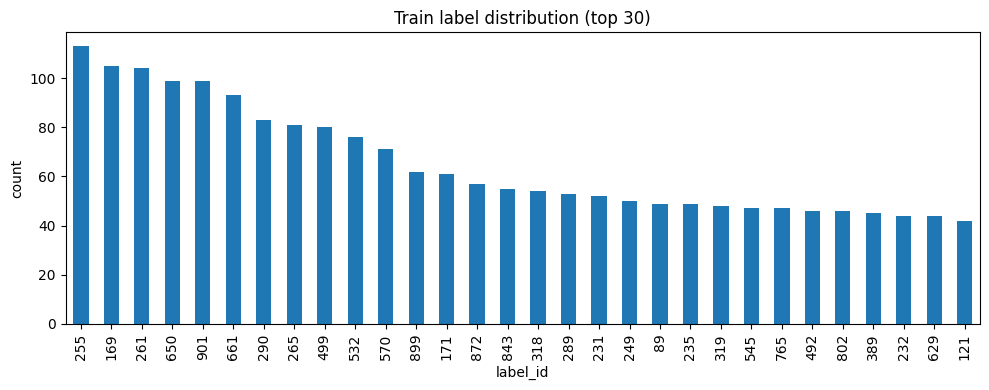

In [9]:
# === Plot: top-k frequent labels in train ===
topk = 30
df_top = df_train_dist.nlargest(topk, "count")
ax = df_top.plot(kind="bar", x="label_id", y="count", legend=False, figsize=(10,4), title=f"Train label distribution (top {topk})")
ax.set_xlabel("label_id"); ax.set_ylabel("count");
plt.tight_layout(); plt.show()

## Task 2: ESCI classification

In this task, we take a **query** (search term) and a **product** (title/description) as input, and train a model to predict one of the four **ESCI labels**:

- **E (Exact):** The product is an exact match to the query  
- **S (Substitute):** The product is not exact but can serve as a substitute  
- **C (Complement):** The product complements or is used together with the queried item  
- **I (Irrelevant):** The product is not relevant to the query  

The goal is to automatically determine the relationship between a user’s query and a product,  
which is a key step in building effective product search and recommendation systems.

In [10]:
train_qrels = pd.read_csv(QRELS_TRAIN_PATH, sep="\t", header=0)
train_qrels.tail(5)

,query-id,corpus-id,label
20298,35946,B00P19IDTU,E
20299,35946,B00P19IEAI,E
20300,35946,B00PX1G96K,E
20301,35946,B006IVN03O,I
20302,35946,B00R57MTQ4,I


In [11]:
examples = {}
for lbl in ["E", "S", "C", "I"]:
    row = train_qrels[train_qrels["label"] == lbl].sample(1).iloc[0]
    qid, did = row["query-id"], row["corpus-id"]
    query_text = df_queries.loc[df_queries["query_id"] == qid, "query"].values[0]
    product_row = df_corpus.loc[df_corpus["_id"] == did].iloc[0]

    examples[lbl] = {
        "label": lbl,
        "query": query_text,
        "product_title": product_row["title"],
        "product_text": product_row["text"][:200] + "..."  # truncate for readability
    }

for lbl, ex in examples.items():
    print(f"Label: {lbl}")
    print(f"Query: {ex['query']}")
    print(f"Product Title: {ex['product_title']}")
    print(f"Product Text: {ex['product_text']}\n")

Label: E
Query: spread love not germs sticker
Product Title: Share Love Hand Sanitizer Labels 2x1.5 Inch Favor Stickers Set of 72 (Blush)
Product Text: Hand sanitizer favor labels are 2 inches tall by 1.5 inches wide. These will fit a variety of hand sanitizer bottles or other wedding favors. Plus with blockout material it will completely hide the la...

Label: S
Query: large container multi colored glitter
Product Title: Kinetic Sand The Original Moldable Sensory Play Sand, Blue, 2 Pounds
Product Text:  Kinetic Sand The Original Moldable Sensory Play Sand, Blue, 2 Pounds...

Label: C
Query: lettuce fresh romaine
Product Title: VeggieZips Premium Produce Bags by Bluapple The Experts in Produce Storage: 22 Bags + 22 HydroLiners to Keep Produce Fresh Longer - Reusable Bags Green Living, Helps to Control Humidity …
Product Text: Bluapple, the experts in produce storage, introduce VeggieZips with HydroLiners, specially designed produce bags that give the user the ability to control the hum

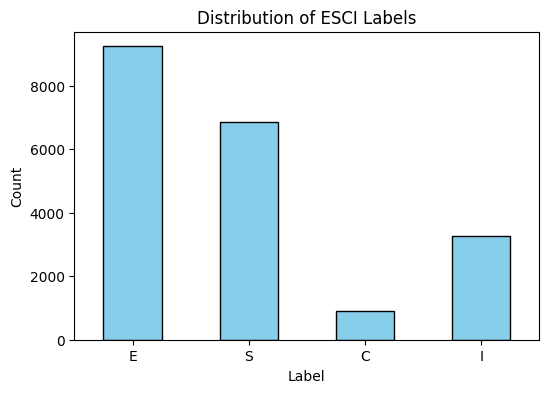

In [12]:
import matplotlib.pyplot as plt

# Count labels
label_order = ["E", "S", "C", "I"]
label_counts = train_qrels["label"].value_counts().reindex(label_order)

# Bar chart
plt.figure(figsize=(6,4))
label_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Distribution of ESCI Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Task 3: Retrieval

In this task, the goal is to build a retrieval system that ranks products for a given query. We treat **all unlabeled items** and those with label **I (Irrelevant)** as *irrelevant*.  
Our goal is to return a **top-20 ranking list** that best reflects the user’s interest from the whole corpus.

For relevance scoring, we assign the following values:
- **E (Exact):** 1.0  
- **S (Substitute):** 0.1  
- **C (Complement):** 0.01  
- **I / Unlabeled:** 0.0  

This scoring scheme allows the retrieval model to focus on exact matches while still considering substitutes and complements, albeit with lower importance.

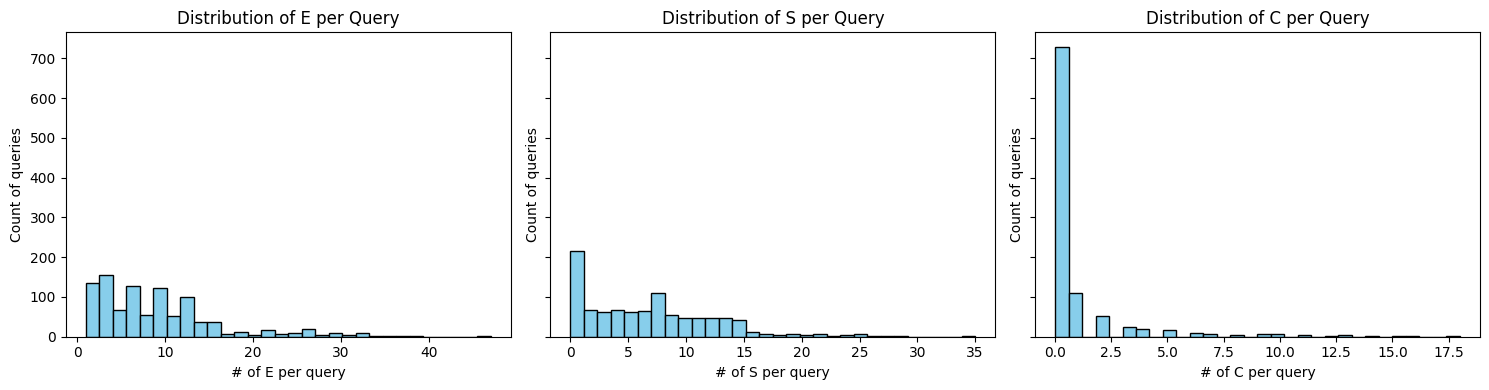

In [13]:
# Count the number of E/S/C labels per query
q_label_counts = (
    train_qrels[train_qrels["label"].isin(["E", "S", "C"])]
    .groupby(["query-id", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["E", "S", "C"], fill_value=0)
)

# Plot histograms for E, S, and C distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, lbl in enumerate(["E", "S", "C"]):
    axes[i].hist(q_label_counts[lbl], bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(f"Distribution of {lbl} per Query")
    axes[i].set_xlabel(f"# of {lbl} per query")
    axes[i].set_ylabel("Count of queries")

plt.tight_layout()
plt.show()